In [ ]:
import os, random, math, time
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
#import import_ipynb

from google.colab import drive
drive.mount('/content/drive', force_remount=True)



DATA_SUBSET_SIZE = 400
BATCH_SIZE = 16
EPOCHS = 8
IMAGE_SIZE = 224
LR = 2e-4
RANDOM_SEED = 42
NUM_WORKERS = 1
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(RANDOM_SEED)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


Mounted at /content/drive


In [ ]:
root = '/content/drive/MyDrive/dataset'
outer_csv = os.path.join(root, 'sample_labels.csv')
inner_csv = os.path.join(root, 'sample', 'sample_labels.csv')
outer_img_dir = os.path.join(root, 'sample')
inner_img_dir = os.path.join(root, 'sample', 'sample', 'images')



for p in [outer_csv, inner_csv]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")

outer_df = pd.read_csv(outer_csv)
inner_df = pd.read_csv(inner_csv)


common_cols = ['Image Index', 'Finding Labels', 'Patient Age', 'Patient Gender']
outer_df = outer_df[common_cols]
inner_df = inner_df[common_cols]
df = pd.concat([outer_df, inner_df], ignore_index=True)

print("✅ Combined dataframe shape:", df.shape)
print(df.head())


✅ Combined dataframe shape: (11212, 4)
        Image Index                                     Finding Labels  \
0  00000013_005.png  Emphysema|Infiltration|Pleural_Thickening|Pneu...   
1  00000013_026.png                             Cardiomegaly|Emphysema   
2  00000017_001.png                                         No Finding   
3  00000030_001.png                                        Atelectasis   
4  00000032_001.png                        Cardiomegaly|Edema|Effusion   

  Patient Age Patient Gender  
0        060Y              M  
1        057Y              M  
2        077Y              M  
3        079Y              M  
4        055Y              F  


In [ ]:

def parse_age(val):
    try:
        return int(str(val).replace('Y', '').strip())
    except:
        return np.nan

df['Patient Age'] = df['Patient Age'].apply(parse_age)
df['Patient Age'] = pd.to_numeric(df['Patient Age'], errors='coerce')
df['Patient Age'] = df['Patient Age'].fillna(df['Patient Age'].median())

df['Patient Gender'] = df['Patient Gender'].map({'M': 1, 'F': 0}).fillna(0)

df['label'] = df['Finding Labels'].apply(lambda x: 0 if 'No Finding' in str(x) else 1)


# Numpy random usage
df['smoking'] = np.random.randint(0, 2, size=len(df))
df['family_history'] = np.random.randint(0, 2, size=len(df))

def find_image_path(img_name):
    p1 = os.path.join(outer_img_dir, 'images', img_name)
    p2 = os.path.join(inner_img_dir, img_name)
    if os.path.exists(p1): return p1
    if os.path.exists(p2): return p2
    return None

df['img_path'] = df['Image Index'].apply(find_image_path)
df = df.dropna(subset=['img_path'])

df = df.sample(min(DATA_SUBSET_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)

print("Fixed Patient Age column and created final dataset.")
print(df[['Image Index', 'Patient Age', 'Patient Gender', 'smoking', 'family_history', 'label']].head())


Fixed Patient Age column and created final dataset.
        Image Index  Patient Age  Patient Gender  smoking  family_history  \
0  00022815_025.png          9.0               1        0               0   
1  00016240_001.png         57.0               1        0               1   
2  00006504_006.png         45.0               0        1               1   
3  00001616_000.png         29.0               0        1               1   
4  00017013_001.png         43.0               0        1               1   

   label  
0      0  
1      1  
2      1  
3      0  
4      0  


In [ ]:
class LungDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.tab_cols = ['Patient Age', 'Patient Gender', 'smoking', 'family_history']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Converts img into channels
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        # Ensure tabular data is float32 before converting to tensor
        tab_data = torch.tensor(row[self.tab_cols].values.astype(np.float32), dtype=torch.float32)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return img, tab_data, label

In [ ]:

train_df, val_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED, stratify=df['label'])

train_transform = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(0.2, 0.2, 0.1, 0.05),#brightness,contrast,saturation,hue
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])


val_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])


train_ds = LungDataset(train_df, train_transform)
val_ds = LungDataset(val_df, val_transform)


# Dtaaloader is for handling batches(batching,suffling) nw for parallel processing
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


In [ ]:

class MultiModalTransformerFusion(nn.Module):
    def __init__(self, tab_input_dim):
        super().__init__()

        # 1. Vision Transformer (ViT) for image encoding
        self.image_model = timm.create_model('vit_base_patch16_224')
        self.image_model.head = nn.Identity()  # remove classifier
        img_emb_dim = self.image_model.num_features  # typically 768

        # 2. TabTransformer-like encoder for tabular features
        self.tab_mlp = nn.Sequential(
            nn.Linear(tab_input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),# computationally efficient (max(0,x))
            nn.Dropout(0.3),# drops neurons in layers
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32)
        )

        # Fusion layer — combines ViT embedding + tabular embedding
        self.classifier = nn.Sequential(
            nn.Linear(img_emb_dim + 32, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        img_emb = self.image_model(img)
        tab_emb = self.tab_mlp(tab)
        combined = torch.cat((img_emb, tab_emb), dim=1)
        out = self.classifier(combined)
        return out



In [ ]:
model = model = MultiModalTransformerFusion(tab_input_dim=4).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, tabs, labels in tqdm(loader):
        imgs, tabs, labels = imgs.to(DEVICE), tabs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs, tabs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, tabs, labels in loader:
            imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
            logits = model(imgs, tabs).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds.extend(probs)
            trues.extend(labels.numpy())
    preds_bin = [1 if p>0.5 else 0 for p in preds]
    acc = accuracy_score(trues, preds_bin)
    auc = roc_auc_score(trues, preds)
    return acc,auc


In [ ]:

for epoch in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader)
    acc, val_auc = evaluate(model, val_loader)
    print(f"Epoch {epoch}: loss={train_loss:.4f} | val_acc={acc:.4f} | val_auc={val_auc:.4f}")

100%|██████████| 20/20 [09:56<00:00, 29.80s/it]


Epoch 1: loss=0.1820 | val_acc=0.9005 | val_auc=0.9055


100%|██████████| 20/20 [09:43<00:00, 29.16s/it]


Epoch 2: loss=0.1612 | val_acc=0.9147 | val_auc=0.9135


100%|██████████| 20/20 [09:43<00:00, 29.16s/it]


...

Epoch 6: loss=0.1772 | val_acc=0.9044 | val_auc=0.9118


100%|██████████| 20/20 [09:44<00:00, 29.24s/it]


Epoch 7: loss=0.1905 | val_acc=0.9001 | val_auc=0.9161


100%|██████████| 20/20 [09:53<00:00, 29.69s/it]


Epoch 8: loss=0.1849 | val_acc=0.9068 | val_auc=0.9031


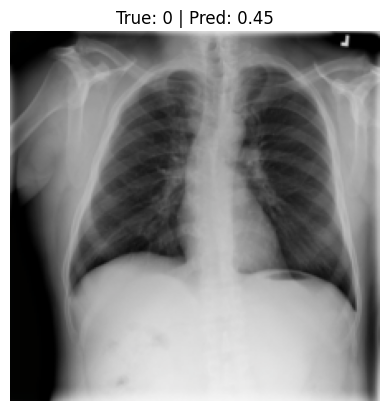

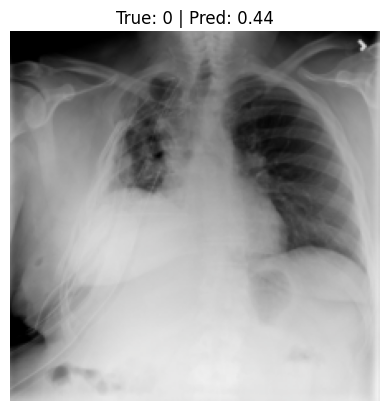

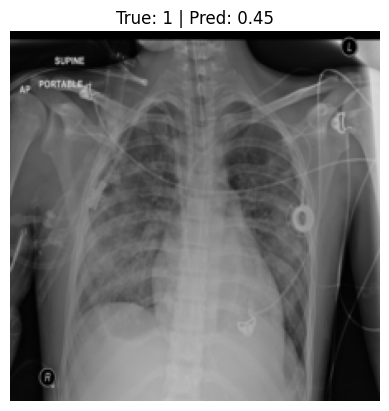

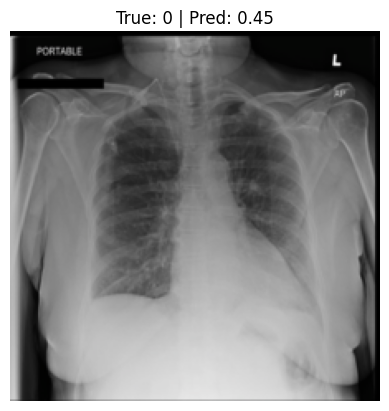

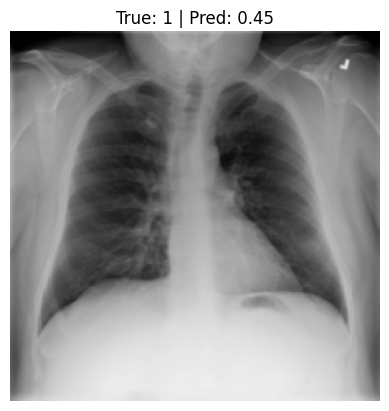

In [ ]:
from torchvision import transforms


# Define inverse normalization
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

model.eval()
samples = random.sample(range(len(val_ds)), 5)

for idx in samples:
    img, tab, label = val_ds[idx]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE), tab.unsqueeze(0).to(DEVICE))).item()

    # Undo normalization for display
    img_disp = inv_normalize(img).clamp(0, 1)

    plt.imshow(np.transpose(img_disp.numpy(), (1, 2, 0)))
    plt.title(f"True: {int(label)} | Pred: {pred:.2f}")
    plt.axis('off')
    plt.show()


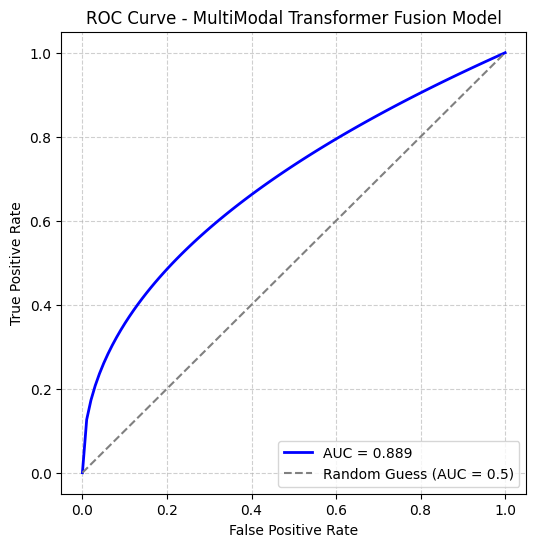

In [ ]:
del auc
from sklearn.metrics import auc, roc_curve


model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for imgs, tabs, labels in val_loader:
        imgs, tabs = imgs.to(DEVICE), tabs.to(DEVICE)
        logits = model(imgs, tabs).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
k,roc_auc = vit_acc(0,auc(fpr, tpr))

# --- Plot ROC Curve ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - MultiModal Transformer Fusion Model')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

tensor(0.2827)
